# F1 Predictor

This time round, we'll be making a model based on the data that we've got. We've chosen to use LightGBM

## Loading the Data

Pretty simple, firstly we load in the libraries that we're going to use and set up some common aliases for them

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, auc, brier_score_loss

Just need to double check we have LightGBM installed

In [3]:
!pip install lightgbm 

In [4]:
import lightgbm as lgb

Then, we proceed to load in all the datasets that we need for the analysis. We leave out the qualifying data as we aknowledged that it will pollute going forward and we can't have that.

In [5]:
race_df = pd.read_csv("../data/races.csv", na_values="\\N", parse_dates=["date", "quali_date"])
race_df.head()

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN


In [6]:
res_df = pd.read_csv("../data/results.csv", na_values="\\N")
res_df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22.0,1.0,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1
1,2,18,2,2,3.0,5.0,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1
2,3,18,3,3,7.0,7.0,3.0,3,3,6.0,58,+8.163,5698779.0,41.0,5.0,1:28.090,216.719,1
3,4,18,4,4,5.0,11.0,4.0,4,4,5.0,58,+17.181,5707797.0,58.0,7.0,1:28.603,215.464,1
4,5,18,5,1,23.0,3.0,5.0,5,5,4.0,58,+18.014,5708630.0,43.0,1.0,1:27.418,218.385,1


In [7]:
constructor_df = pd.read_csv("../data/constructors.csv")
constructor_df.head()

,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


In [8]:
drivers_df = pd.read_csv("../data/drivers.csv", na_values="\\N", parse_dates=["dob"])
drivers_df.head()

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14.0,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,NaN,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [9]:
status_df = pd.read_csv("../data/status.csv", na_values="\\N")
status_df.head()

,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


## Making the Model

First up, we take out datasets and then merge them together so that we have a wide dataframe rather than separate dataframes, we also only select the features that we care about from each respective frame.

Secondly, we create the "podiumFinish" feature which is just if a driver finished in the top 3 for that particular race, having this as a binary column just simplifies some of the work later on when we feed it into LightGBM

In [10]:
full_race_data_df = pd.merge(
    left=res_df[["resultId", "raceId","driverId", "constructorId", "position", "statusId"]],
    right=race_df[["raceId","year","round","circuitId","name","date"]],
    on="raceId"
)

full_race_data_df = pd.merge(
    left=full_race_data_df,
    right=drivers_df[["driverId","dob","nationality"]],
    on="driverId"
)

full_race_data_df["podiumFinish"] = (full_race_data_df["position"] <= 3).astype(int)

full_race_data_df

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,date,dob,nationality,podiumFinish
0,1,18,1,1,1.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1985-01-07,British,1
1,2,18,2,2,2.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1977-05-10,German,1
2,3,18,3,3,3.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1985-06-27,German,1
3,4,18,4,4,4.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1981-07-29,Spanish,0
4,5,18,5,1,5.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1981-10-19,Finnish,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27299,27305,1171,4,117,18.0,11,2026,3,22,Japanese Grand Prix,2026-03-29,1981-07-29,Spanish,0
27300,27306,1171,822,216,19.0,11,2026,3,22,Japanese Grand Prix,2026-03-29,1989-08-28,Finnish,0
27301,27307,1171,848,3,20.0,12,2026,3,22,Japanese Grand Prix,2026-03-29,1996-03-23,Thai,0
27302,27308,1171,840,117,21.0,34,2026,3,22,Japanese Grand Prix,2026-03-29,1998-10-29,Canadian,0


We're using 2025 as our test set, so we need to make sure that we only do any kind of training on data *before* 2025

In [11]:
training_race_data_df = full_race_data_df[full_race_data_df["year"] < 2025].copy()
training_race_data_df

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,date,dob,nationality,podiumFinish
0,1,18,1,1,1.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1985-01-07,British,1
1,2,18,2,2,2.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1977-05-10,German,1
2,3,18,3,3,3.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1985-06-27,German,1
3,4,18,4,4,4.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1981-07-29,Spanish,0
4,5,18,5,1,5.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1981-10-19,Finnish,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26754,26760,1144,825,210,16.0,11,2024,24,24,Abu Dhabi Grand Prix,2024-12-08,1992-10-05,Danish,0
26755,26761,1144,859,215,17.0,5,2024,24,24,Abu Dhabi Grand Prix,2024-12-08,2002-02-11,New Zealander,0
26756,26762,1144,822,15,NaN,130,2024,24,24,Abu Dhabi Grand Prix,2024-12-08,1989-08-28,Finnish,0
26757,26763,1144,861,3,NaN,5,2024,24,24,Abu Dhabi Grand Prix,2024-12-08,2003-05-27,Argentinian,0


Now we're setting up the actual train/test splits. It's important here that we identify the categorical columns in the dataset, this prevents a situation later on with LightGBM where when it's fed categorical data it doesn't think that a larger difference between enum values for categorical variables somehow represents a more "significant" split which will mess with our results.

We do a train/valdiation split as well - what we do here is that we keep 2023 and back as the training set and we'll use 2024 as the valiation split.

We need to do it this way because the data is time series, if for example we trained on 1990-2024 but used 2000 as the validation set there is a large amount of future data that is going to artificially inflate the performance of the model which we don't have in reality, so it's of critical importance that we do the split this way.

In [12]:
features = ["driverId", "constructorId", "circuitId", "year", "round"]
cat_features = ["driverId", "constructorId", "circuitId"]

for col in cat_features:
    training_race_data_df[col] = training_race_data_df[col].astype("category")

X = training_race_data_df[features]
y = training_race_data_df["podiumFinish"]

In [13]:
train_mask = training_race_data_df["year"] <= 2023
val_mask   = (training_race_data_df["year"] > 2023) & (training_race_data_df["year"] < 2025)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]

Finally, we create the model and fit it to our testing data:
* 500 estimators isn't a bad starting point, normally it's 100 but for a first pass we want to be a bit more comprehensive
* we drop the default learning rate from 0.1 to 0.05, it makes it take a bit longer but again for a first pass we can be more conservative
* num_leaves just says how many leaves we want per tree, this reduces some degree of overfitting
* min_child_samples if a split would result in less than 20 leaves in the branch then we don't do it. This also helps to prevent some degree of overfitting as well
* verbosity we turn off

In [14]:
model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    verbose=-1
)

model.fit(
    X_train, y_train,
    categorical_feature=cat_features,
    eval_set=[(X_val, y_val)],
)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Checking Model Validation Performance

Then, we can proceed to generate the AUC and Brier scores for our model

In [15]:
val_preds = model.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, val_preds)
auc  = roc_auc_score(y_val, val_preds)
brier = brier_score_loss(y_val, val_preds)

print(f"AUC:   {auc:.4f}  (baseline: 0.79)")
print(f"Brier: {brier:.4f}  (baseline: 0.12)")

AUC:   0.8284  (baseline: 0.79)
Brier: 0.1228  (baseline: 0.12)


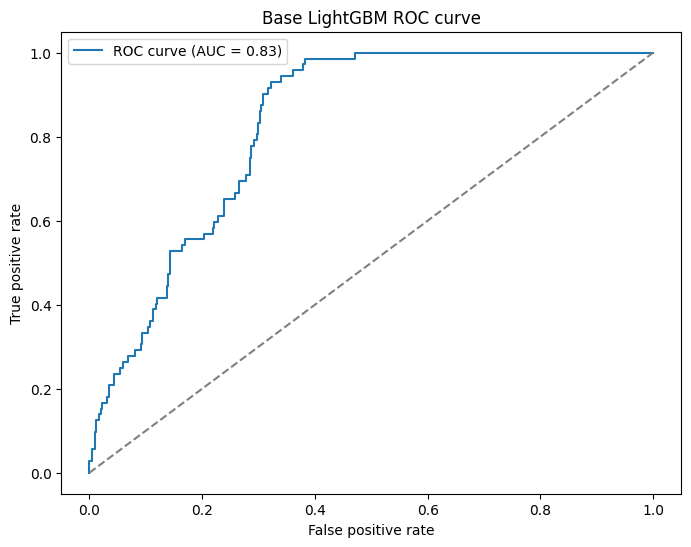

In [16]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Base LightGBM ROC curve')
plt.legend()
plt.show()

The LightGBM model library that we use has feature importance provided out of the box

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

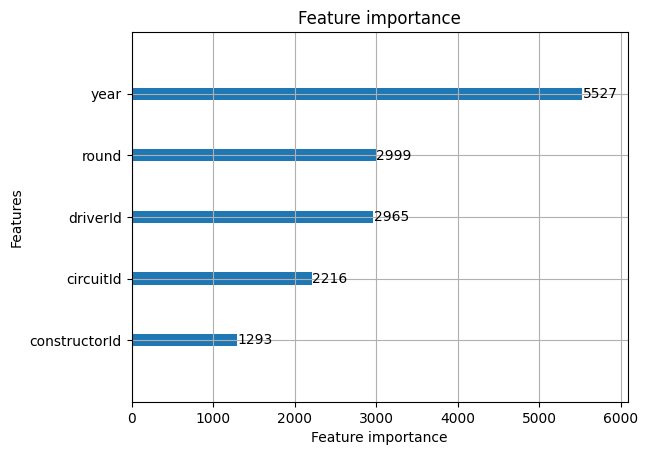

In [17]:
lgb.plot_importance(model)

Sklearn has a calibration curve function that we can use to generate a graph of predicted vs actual probabilities for the model. We also add in the line for perfect calibration as well into the legend so that we have a point of comparison.

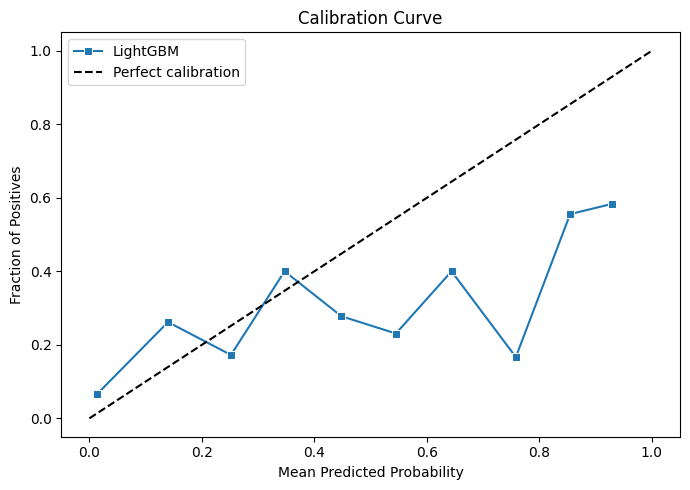

In [18]:
import seaborn as sns
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import pandas as pd

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_val, val_preds, n_bins=10
)

calib_df = pd.DataFrame({
    "Mean Predicted Probability": mean_predicted_value,
    "Fraction of Positives": fraction_of_positives
})

fig1, ax1 = plt.subplots(figsize=(7, 5))
sns.lineplot(
    data=calib_df,
    x="Mean Predicted Probability",
    y="Fraction of Positives",
    marker="s", label="LightGBM", ax=ax1
)
ax1.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax1.set_title("Calibration Curve")
ax1.legend()
plt.tight_layout()
plt.show()

Prediction distribution is also possible using histplots. What we are expecting to see here is a clear separation of distributions between the two as evidence that our model can easily distinguish podium from non-podium results based on the input variables.

What we see instead is that the distributions are largely the same and a significant amount of "guesses" are all piled into "No Podium" which underscores the lack of confidence in the model

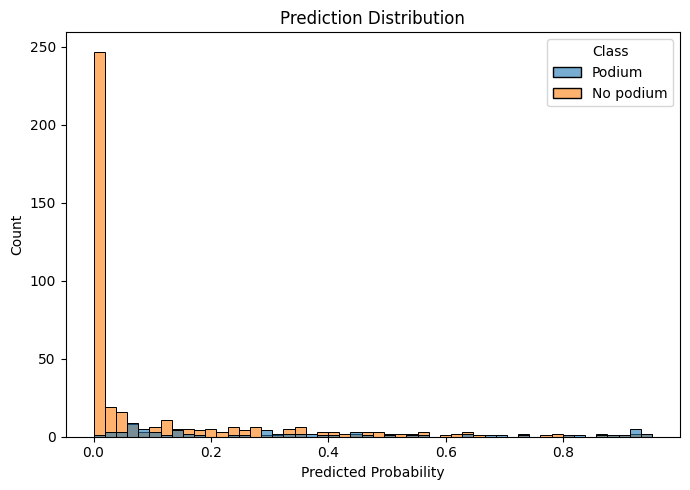

In [19]:
dist_df = pd.DataFrame({
    "Predicted Probability": val_preds,
    "Class": ["Podium" if y == 1 else "No podium" for y in y_val]
})

fig2, ax2 = plt.subplots(figsize=(7, 5))
sns.histplot(
    data=dist_df,
    x="Predicted Probability",
    hue="Class",
    bins=50,
    alpha=0.6,
    ax=ax2
)
ax2.set_title("Prediction Distribution")
plt.tight_layout()
plt.show()

## Performance Against Test Set

In [20]:
test_race_data_df = full_race_data_df[full_race_data_df["year"] == 2025].copy()

for col, cats in zip(cat_features, model._Booster.pandas_categorical):
    test_race_data_df[col] = pd.Categorical(test_race_data_df[col], categories=cats)

X_test = test_race_data_df[features]
y_test = test_race_data_df["podiumFinish"]

test_preds = model.predict_proba(X_test)[:, 1]

In [21]:
fpr, tpr, thresholds = roc_curve(y_test, test_preds)
auc  = roc_auc_score(y_test, test_preds)
brier = brier_score_loss(y_test, test_preds)

print(f"AUC:   {auc:.4f}  (baseline: 0.79)")
print(f"Brier: {brier:.4f}  (baseline: 0.12)")

AUC:   0.8116  (baseline: 0.79)
Brier: 0.1215  (baseline: 0.12)


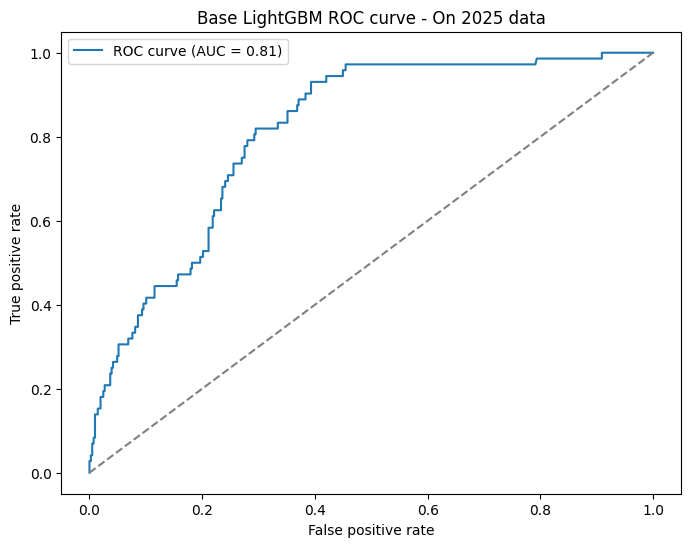

In [22]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Base LightGBM ROC curve - On 2025 data')
plt.legend()
plt.show()